In [2]:
import pandas as pd
import numpy as np
import importlib

from matplotlib.lines import Line2D
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
def generate_noisy_dataset(f_true, random_state: int, n:int=50, sigma:float=0.2, x_range:list=(0.0, 1.0), noise_free:bool=False):
    """
    Generate a random dataset based on a given known function f(x).
    :param random_state:
    :param n:
    :param sigma:
    :param x_range:
    :return:
    """

    np.random.seed(random_state)
    X = np.random.uniform(x_range[0], x_range[1], size=n)
    X = np.sort(X)

    # Noise
    noise = np.random.normal(0, sigma, size=n) if not noise_free else 0
    y = f_true(X) + noise

    return X.reshape(-1, 1), y


def plot_true_vs_custom(f_true, predictions, x_range=(0, 1), n_grid=300, show_true:bool=True, show_mean:bool=True, title:str= "Bias–Variance Visualization"):

    x_grid = np.linspace(x_range[0], x_range[1], n_grid)
    y_true = f_true(x_grid)

    predictions = np.array(predictions)

    plt.figure(figsize=(8,6))

    # tutte le curve
    for pred in predictions:
        sns.lineplot(x=x_grid, y=pred, alpha=0.3, color="orange")

    # mean
    if show_mean:
        mean_pred = predictions.mean(axis=0)
        sns.lineplot(x=x_grid, y=mean_pred, linewidth=1, color="red", label="Mean h(x)")

    # Real function
    if show_true:
        sns.lineplot(x=x_grid, y=y_true, alpha=0.5, linewidth=3, label="True f(x)")

    # legenda custom
    handles, labels = plt.gca().get_legend_handles_labels()
    handles.append(Line2D([0], [0], color="orange", lw=2, alpha=0.7))
    labels.append("Generated")
    plt.legend(handles, labels)

    plt.title(title)
    plt.grid(True)
    plt.show()

In [4]:

def f_true_harmonics(x):
    #return np.sin(2*np.pi*x)
    return np.sin(2*np.pi*x) + 0.3*np.sin(6*np.pi*x)
    #return x

def f_true_highfreq(x):
    """
    Perfetta per vedere che degree basso ha bias, degree alto rincorre rumore.
    :param x:
    :return:
    """
    x = np.asarray(x)
    return np.sin(2*np.pi*x) + 0.5*np.sin(20*np.pi*x)

def f_true_piecewise(x):
    """
    Ottima perché i polinomi fanno fatica vicino allo “spigolo”.
    :param x:
    :return:
    """
    x = np.asarray(x)
    return np.sin(2*np.pi*x) + 0.5*np.sin(20*np.pi*x)

def f_true_stepfunction(x):
    """
    Qui l’overfitting è quasi garantito con modelli troppo flessibili.
    :param x:
    :return:
    """
    x = np.asarray(x)
    return (x > 0.5).astype(float)

def f_true_gaussian(x, s1=0.06, s2=0.08):
    """
    Molto usata per mostrare smoothing vs rincorsa del rumore.
    :param x:
    :param s1:
    :param s2:
    :return:
    """
    x = np.asarray(x)
    return np.exp(-((x-0.25)**2)/(2*s1**2)) - 0.8*np.exp(-((x-0.75)**2)/(2*s2**2))

In [5]:
set_size = 100
f_true = f_true_piecewise

datasets = []
for i in range(27):
    datasets.append(generate_noisy_dataset(f_true, random_state=i*10, n=set_size, sigma=0.50))

noise_free_dataset = generate_noisy_dataset(f_true, random_state=99, n=set_size, sigma=0, noise_free=True)

In [6]:
X_tr, y_tr = datasets[0][0], datasets[0][1]
X_ts, y_ts = datasets[1][0], datasets[1][1]
X_nf, y_nf = noise_free_dataset[0], noise_free_dataset[1]

test_datasets = datasets[2:]

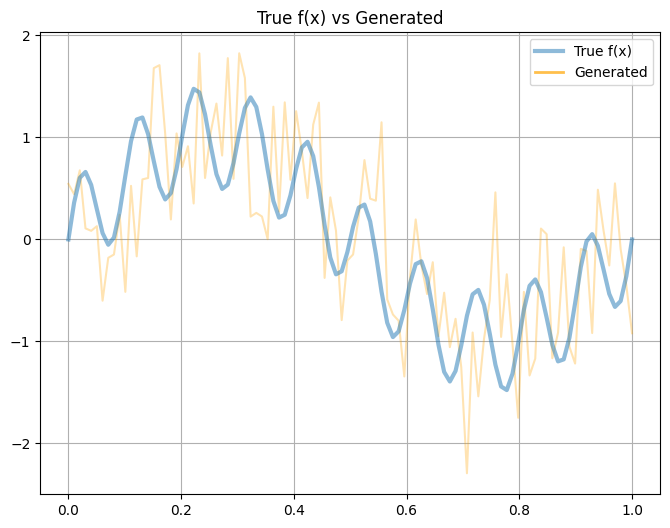

In [7]:
plot_true_vs_custom(f_true, [test_datasets[10][1]], n_grid=y_ts.shape[0], show_mean=False, title="True f(x) vs Generated")

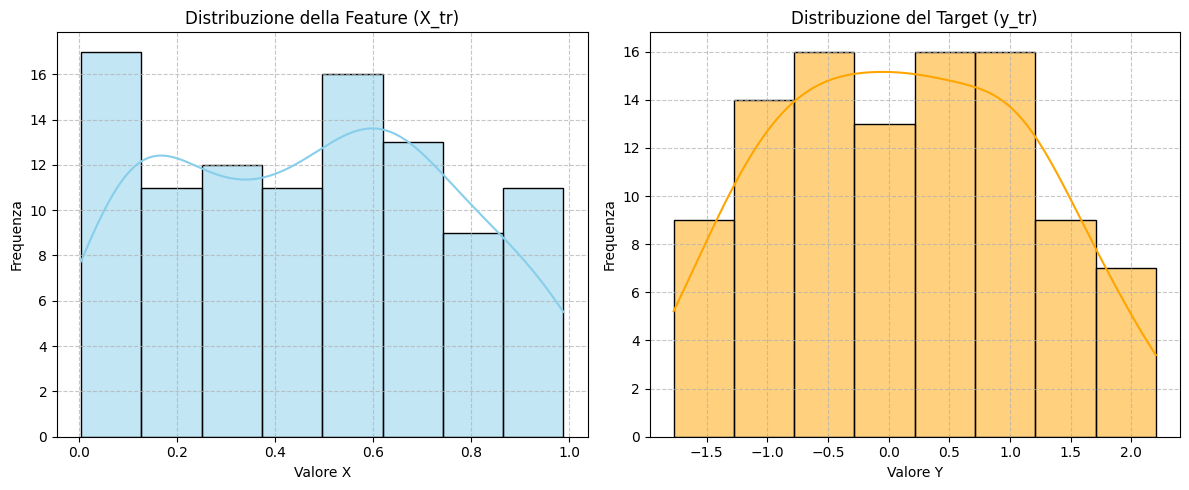

In [17]:
plt.figure(figsize=(12, 5))

# Plot per la feature (X_tr)
plt.subplot(1, 2, 1) # 1 riga, 2 colonne, 1° subplot
sns.histplot(X_tr.flatten(), kde=True, color='skyblue')
plt.title('Distribuzione della Feature (X_tr)')
plt.xlabel('Valore X')
plt.ylabel('Frequenza')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot per il target (y_tr)
plt.subplot(1, 2, 2) # 1 riga, 2 colonne, 2° subplot
sns.histplot(y_tr, kde=True, color='orange')
plt.title('Distribuzione del Target (y_tr)')
plt.xlabel('Valore Y')
plt.ylabel('Frequenza')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<h2>GridsearchCV</h2>

In [8]:
from scipy.linalg import LinAlgWarning
import warnings

warnings.filterwarnings("ignore", category=LinAlgWarning)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("ridge", Ridge())
    #("linear", LinearRegression()),
])

param_grid = {
    "poly__degree": range(1,40),
    "ridge__alpha": np.logspace(-4, 2, 7)
}

grid = GridSearchCV(pipe, param_grid, cv=5)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid.fit(X_tr, y_tr)
best_estimator = grid.best_estimator_

In [9]:
print(best_estimator)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=3, include_bias=False)),
                ('ridge', Ridge(alpha=np.float64(0.0001)))])


In [10]:
y_pred = best_estimator.predict(X_ts)

mse = mean_squared_error(y_ts, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_ts, y_pred)
r2 = r2_score(y_ts, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 0.39164352845020084
RMSE: 0.6258142923025974
MAE : 0.4935021634035589
R2  : 0.5546102573437266


<h2>Bias-variance simulator</h2>

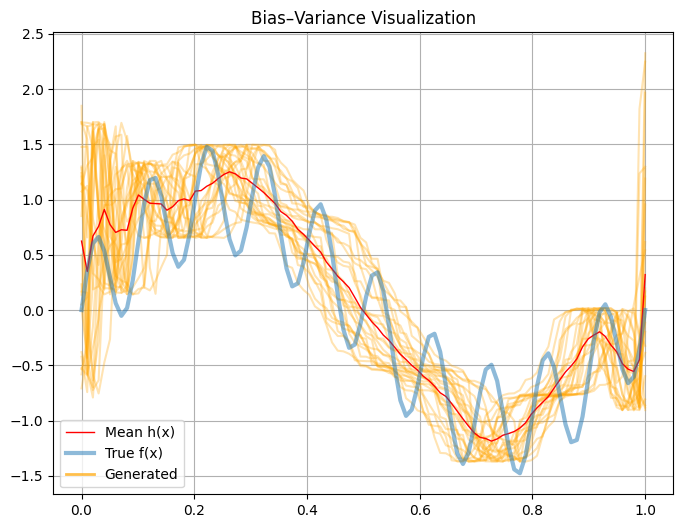

In [11]:
degree = 20 # complexity
alpha = 0 # variance (Increased regularization)

manual_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
    #("linear", LinearRegression()),
    ("ridge", Ridge(alpha=alpha))
])


model = clone(manual_model)
model.fit(X_tr, y_tr)

predictions, scores = [], []
for dataset in test_datasets:
    X_local, y_true_local = dataset[0], dataset[1]
    y_pred_local = model.predict(X_local)
    predictions.append(y_pred_local)
    mse = mean_squared_error(y_true_local, y_pred_local)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_local, y_pred_local)
    r2 = r2_score(y_true_local, y_pred_local)
    scores.append((mse,rmse,mae,r2))

plot_true_vs_custom(f_true, predictions, n_grid=y_ts.shape[0])

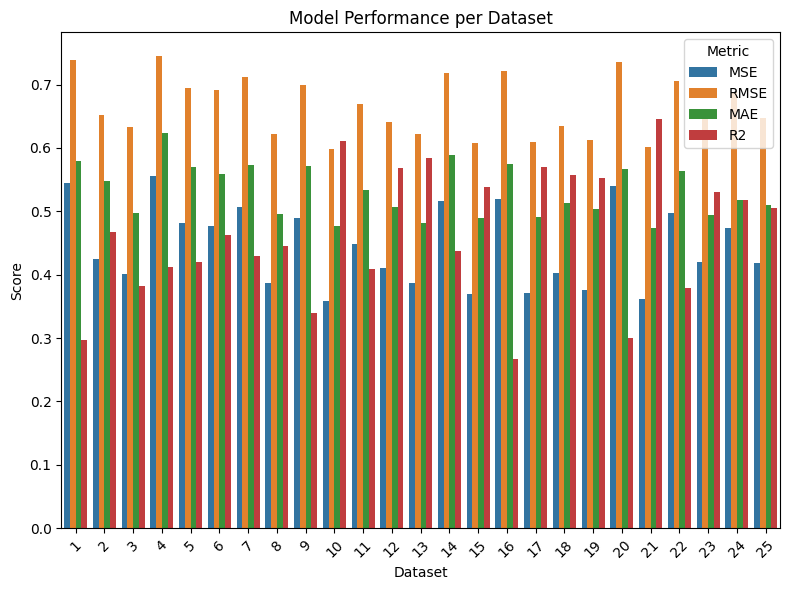

In [12]:

df_scores = pd.DataFrame(
    scores,
    columns=["MSE", "RMSE", "MAE", "R2"]
)

df_scores["Dataset"] = range(1, len(df_scores) + 1)
df_long = df_scores.melt(id_vars="Dataset",var_name="Metric",value_name="Score")

plt.figure(figsize=(8,6))

sns.barplot(data=df_long, x="Dataset", y="Score", hue="Metric")

plt.title("Model Performance per Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
y_pred = model.predict(X_ts)

mse = mean_squared_error(y_ts, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_ts, y_pred)
r2 = r2_score(y_ts, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


MSE : 0.3710841195129213
RMSE: 0.6091667419622655
MAE : 0.4744296600693296
R2  : 0.5779910850366432


In [14]:
y_pred_tr = model.predict(X_tr)
y_pred_ts = model.predict(X_ts)

print("Train R2:", r2_score(y_tr, y_pred_tr))
print("Test  R2:", r2_score(y_ts, y_pred_ts))

print("Train RMSE:", np.sqrt(mean_squared_error(y_tr, y_pred_tr)))
print("Test  RMSE:", np.sqrt(mean_squared_error(y_ts, y_pred_ts)))

Train R2: 0.7219349751436217
Test  R2: 0.5779910850366432
Train RMSE: 0.5365766474908947
Test  RMSE: 0.6091667419622655


In [15]:
y_nf_pred = model.predict(X_nf)

mse = mean_squared_error(y_nf, y_nf_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_nf, y_nf_pred)
r2 = r2_score(y_nf, y_nf_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 0.17919508072258064
RMSE: 0.42331439938015414
MAE : 0.3469714292794114
R2  : 0.6476782673161912
